In [1]:
%load_ext autoreload
%autoreload 2

# Import delle librerie e dei moduli locali
from pathlib import Path
import sys
import numpy as np
import pandas as pd
from torch_geometric.loader import DataLoader
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

# Individuazione root del progetto per permettere gli import di 'src'
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src import config as cfg
from src import utils as ut
from src import data_loader as dl
from src import train as tr
from src import models as mdl

# Setup Riproducibilità e Device
ut.setup_reproducibility(cfg.FIXED_SEED)
device = ut.get_device()
print(f"Addestramento rete neurale attraverso: {device}")

# Caricamento e validazione dataset
dataset = dl.load_and_validate_dataset(str(cfg.DATASET_PATH))

# Analisi features
dl.inspect_node_features(dataset)

# Analisi dello sbilanciamento delle classi
distribution = dl.check_class_imbalance(dataset)

# Separazione del Test Set finale (Holdout sicuro)
train_val_dataset, test_dataset = dl.stratified_holdout_split(dataset, cfg.TEST_SIZE, cfg.FIXED_SEED)

[INFO] Configurazione di riproducibilità completata con Seed: 42
Addestramento rete neurale attraverso: cpu
[INFO] Dataset caricato con successo. Numero totale di grafi: 1001

===== FEATURE INSPECTION =====
Feature 00 | min=-3.0000 | max=7864.0000 | mean=314.5222 | std=668.1120 | median=169.0000 | unique=2169
Feature 01 | min=2.0000 | max=7878.0000 | mean=321.3714 | std=668.1279 | median=176.0000 | unique=2153
Feature 02 | min=-538.0000 | max=798.0000 | mean=7.8492 | std=13.0874 | median=6.0000 | unique=57
Feature 03 | min=0.0000 | max=120.2704 | mean=12.4293 | std=9.0114 | median=10.8248 | unique=32568
Feature 04 | min=-1.0000 | max=1.0000 | mean=-0.1117 | std=0.5899 | median=0.0000 | unique=3
Feature 05 | min=0.0000 | max=215.6000 | mean=2.9932 | std=3.7552 | median=2.3600 | unique=1222
Feature 06 | min=-13.0500 | max=14.4200 | mean=0.4753 | std=1.2894 | median=0.2900 | unique=871
Feature 07 | min=0.0000 | max=347.7500 | mean=4.4936 | std=5.8753 | median=3.4700 | unique=1658
Feature 

In [2]:
# Griglia di iperparametri (4 combinazioni totali per non appesantire la CPU)
grid_lr = [1e-3, 1e-4]
grid_dropout = [0.1, 0.3]

# Lista di indici delle feature da non normalizzare
excluded_indexes = [4, 29, 30, 31]

results_archive = {}

print("\n=========================================")
print("AVVIO GRID SEARCH: GCN & GAT")
print("=========================================\n")

print("\n[INFO]: Avvio procedura di Cross Validation...")
print("[INFO]: Impostata applicazione Z-Score e Noise Injection in modo isolato all'interno di ciascun fold.\n")

for model_name, model_class in [("GCN", mdl.ProteinGCN), ("GAT", mdl.ProteinGAT)]:
    # print(f"\n Valutazione Architettura: Protein{model_name}")
    print(f"\n VALUTAZIONE ARCHITETTURA: Protein{model_name}")
    for lr in grid_lr:
        for drop in grid_dropout:
            config_name = f"{model_name}_lr_{lr}_drop_{drop}"
            print(f"\n>> Testando configurazione: {config_name}")
            
            f1_res, auc_res = tr.run_cross_validation(
                dataset=train_val_dataset,
                model_class=model_class,
                n_splits=cfg.N_SPLITS,
                train_fold_fn=tr.train_single_fold,
                lr=lr,
                dropout_p=drop,
                hidden_channels=cfg.DEFAULT_HIDDEN_CHANNELS,
                excluded_features=excluded_indexes,
                noise_level=cfg.NOISE_LEVEL
            )
            results_archive[config_name] = {
                "model": model_name, "lr": lr, "dropout": drop, "channels": cfg.DEFAULT_HIDDEN_CHANNELS,
                "f1_mean": np.mean(f1_res), "f1_std": np.std(f1_res),
                "auc_mean": np.mean(auc_res), "auc_std": np.std(auc_res)
            }

print("\n[INFO]: Lavoro completato.")


AVVIO GRID SEARCH: GCN & GAT


[INFO]: Avvio procedura di Cross Validation...
[INFO]: Impostata applicazione Z-Score e Noise Injection in modo isolato all'interno di ciascun fold.


 VALUTAZIONE ARCHITETTURA: ProteinGCN

>> Testando configurazione: GCN_lr_0.001_drop_0.1

   --- FOLD 1/3 ---
   [Epoca 01/50] Training Loss: 0.6713
   [Epoca 10/50] Training Loss: 0.4323
   [Epoca 20/50] Training Loss: 0.3667
   [Epoca 30/50] Training Loss: 0.2997
   [Epoca 40/50] Training Loss: 0.2320
   [Epoca 50/50] Training Loss: 0.1542
   Risultati Fold 1 | Macro F1: 0.7297 | ROC-AUC: 0.7759

   --- FOLD 2/3 ---
   [Epoca 01/50] Training Loss: 0.6757
   [Epoca 10/50] Training Loss: 0.4744
   [Epoca 20/50] Training Loss: 0.3878
   [Epoca 30/50] Training Loss: 0.3267
   [Epoca 40/50] Training Loss: 0.2699
   [Epoca 50/50] Training Loss: 0.1825
   Risultati Fold 2 | Macro F1: 0.7380 | ROC-AUC: 0.7973

   --- FOLD 3/3 ---
   [Epoca 01/50] Training Loss: 0.6701
   [Epoca 10/50] Training Loss: 0.4604
   [E

In [6]:
df_results = pd.DataFrame.from_dict(results_archive, orient="index").sort_values(by="f1_mean", ascending=False)

# Esportazione della tabella in formato CSV
cfg.RESULTS_DIR.mkdir(exist_ok=True)
df_results.to_csv(cfg.RESULTS_DIR / "grid_search_results.csv", float_format="%.4f")

# Stampa della tabella con le informazioni di interesse
print("\n TABELLA COMPARATIVA DELLE CONFIGURAZIONI (CROSS-VALIDATION) ")
df_display = (
    df_results
    .reset_index()
    .rename(columns={'index': 'Configurazione'})
)

df_styled = (
    df_display.style
    .hide(axis="index")
    .hide(subset=["model", "lr", "dropout", "channels"], axis="columns")
    .format(precision=4)
)

display(df_styled)

# Estrazione automatica del modello vincente
selected_config = df_results.iloc[0]
best_model_class = mdl.ProteinGCN if selected_config["model"] == "GCN" else mdl.ProteinGAT

# print(f"selected_config: {selected_config}\n")

print("\n=======================================================================")
print(f" MODELLO VINCITORE SELEZIONATO: {selected_config.name}")
print(f" - Macro F1 Medio in CV: {selected_config['f1_mean']:.4f}")
print(f" - ROC-AUC Medio in CV: {selected_config['auc_mean']:.4f}")
print("=======================================================================\n")



 TABELLA COMPARATIVA DELLE CONFIGURAZIONI (CROSS-VALIDATION) 


Configurazione,f1_mean,f1_std,auc_mean,auc_std
GCN_lr_0.001_drop_0.3,0.7393,0.0021,0.7922,0.0091
GAT_lr_0.001_drop_0.3,0.7309,0.0192,0.7963,0.0308
GCN_lr_0.0001_drop_0.3,0.7296,0.0253,0.7973,0.0162
GAT_lr_0.0001_drop_0.1,0.7272,0.0223,0.8002,0.0325
GCN_lr_0.001_drop_0.1,0.7223,0.0166,0.7854,0.0089
GCN_lr_0.0001_drop_0.1,0.7185,0.0282,0.7888,0.0155
GAT_lr_0.001_drop_0.1,0.7090,0.0127,0.7864,0.0282
GAT_lr_0.0001_drop_0.3,0.7074,0.0274,0.8019,0.0264



 MODELLO VINCITORE SELEZIONATO: GCN_lr_0.001_drop_0.3
 - Macro F1 Medio in CV: 0.7393
 - ROC-AUC Medio in CV: 0.7922



Analisi Comparativa della Preparazione dei Dati

   --- FOLD 1/3 ---
   [Epoca 01/50] Training Loss: 0.6775
   [Epoca 10/50] Training Loss: 0.4639
   [Epoca 20/50] Training Loss: 0.3937
   [Epoca 30/50] Training Loss: 0.3171
   [Epoca 40/50] Training Loss: 0.2424
   [Epoca 50/50] Training Loss: 0.1825
   Risultati Fold 1 | Macro F1: 0.7166 | ROC-AUC: 0.7640

   --- FOLD 2/3 ---
   [Epoca 01/50] Training Loss: 0.6721
   [Epoca 10/50] Training Loss: 0.4928
   [Epoca 20/50] Training Loss: 0.4125
   [Epoca 30/50] Training Loss: 0.3320
   [Epoca 40/50] Training Loss: 0.2700
   [Epoca 50/50] Training Loss: 0.1886
   Risultati Fold 2 | Macro F1: 0.7628 | ROC-AUC: 0.8010

   --- FOLD 3/3 ---
   [Epoca 01/50] Training Loss: 0.6670
   [Epoca 10/50] Training Loss: 0.4840
   [Epoca 20/50] Training Loss: 0.4193
   [Epoca 30/50] Training Loss: 0.3780
   [Epoca 40/50] Training Loss: 0.2901
   [Epoca 50/50] Training Loss: 0.2144
   Risultati Fold 3 | Macro F1: 0.7100 | ROC-AUC: 0.7922

>> COMPILAZIONE

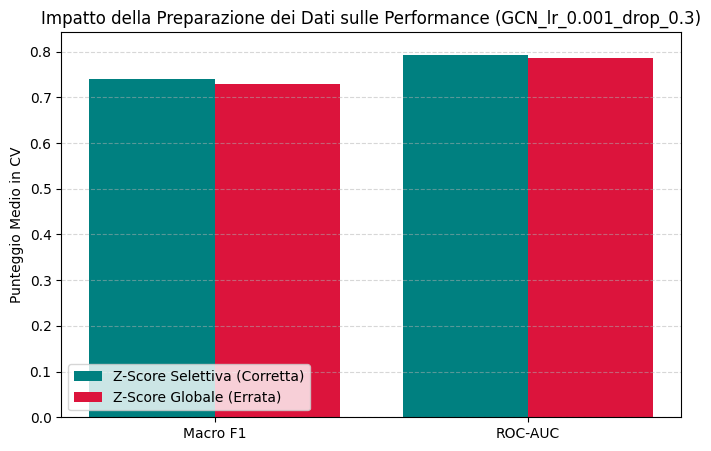

In [7]:
# Esperimento di confronto: Data Preparation

print("=======================================================================")
print("Analisi Comparativa della Preparazione dei Dati")
print("=======================================================================")

# Test con configurazione vincente ma con Z-Score ERRATA (analizzando tutte le feature)
f1_wrong, auc_wrong = tr.run_cross_validation(
    dataset=train_val_dataset,
    model_class=best_model_class,
    n_splits=cfg.N_SPLITS,
    batch_size=cfg.DEFAULT_BATCH_SIZE,
    train_fold_fn=tr.train_single_fold,
    seed=cfg.FIXED_SEED,
    lr=selected_config['lr'],
    dropout_p=selected_config['dropout'],
    hidden_channels=cfg.DEFAULT_HIDDEN_CHANNELS,
    excluded_features=None,    # Nessuna feature viene esclusa
    noise_level=cfg.NOISE_LEVEL
)

# Recupero punteggi della configurazione corretta dall'archivio precedente
correct_f1_mean = selected_config['f1_mean']
correct_auc_mean = selected_config['auc_mean']

wrong_f1_mean = np.mean(f1_wrong)
wrong_auc_mean = np.mean(auc_wrong)

print("\n>> COMPILAZIONE GRAFICO COMPARATIVO DATA PREPARATION...")
metrics_label = ['Macro F1', 'ROC-AUC']
correct_scores = np.array(
    [correct_f1_mean, correct_auc_mean],
    dtype=float
)
wrong_scores = np.array(
    [wrong_f1_mean, wrong_auc_mean],
    dtype=float
)

x_axis = np.arange(len(metrics_label))
plt.figure(figsize=(8, 5))
plt.bar(x_axis - 0.2, correct_scores, 0.4, label='Z-Score Selettiva (Corretta)', color='teal')
plt.bar(x_axis + 0.2, wrong_scores, 0.4, label='Z-Score Globale (Errata)', color='crimson')

plt.xticks(x_axis, metrics_label)
plt.ylabel("Punteggio Medio in CV")
plt.title(f"Impatto della Preparazione dei Dati sulle Performance ({selected_config.name})")

# Adattamento dinamico dell'asse Y per massimizzare la leggibilità del confronto
max_score = max(np.max(correct_scores), np.max(wrong_scores))
plt.ylim(0, max_score + 0.05)

plt.legend(loc="lower left")
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Esportazione immagine plot
plt.savefig(cfg.RESULTS_DIR / "data_preparation_comparison.png", dpi=300, bbox_inches='tight')

plt.show()

plt.close()

In [8]:
# Ulteriore esperimento di configurazione architetturale 

print("\n=======================================================================")
print(f"Avvio analisi di sensibilità architetturale (hidden_channel: {cfg.ALT_HIDDEN_CHANNELS})")
print("=======================================================================")

f1_spot, auc_spot = tr.run_cross_validation(
    dataset=train_val_dataset,
    model_class=best_model_class,
    n_splits=cfg.N_SPLITS,
    batch_size=cfg.DEFAULT_BATCH_SIZE,
    train_fold_fn=tr.train_single_fold,
    seed=cfg.FIXED_SEED,
    lr=selected_config['lr'],
    dropout_p=selected_config['dropout'],
    hidden_channels=cfg.ALT_HIDDEN_CHANNELS,    # Modifica strutturale
    excluded_features=excluded_indexes,
    noise_level=cfg.NOISE_LEVEL
)


Avvio analisi di sensibilità architetturale (hidden_channel: 32)

   --- FOLD 1/3 ---
   [Epoca 01/50] Training Loss: 0.7026
   [Epoca 10/50] Training Loss: 0.5330
   [Epoca 20/50] Training Loss: 0.4541
   [Epoca 30/50] Training Loss: 0.4250
   [Epoca 40/50] Training Loss: 0.3798
   [Epoca 50/50] Training Loss: 0.3312
   Risultati Fold 1 | Macro F1: 0.7396 | ROC-AUC: 0.8009

   --- FOLD 2/3 ---
   [Epoca 01/50] Training Loss: 0.6772
   [Epoca 10/50] Training Loss: 0.5316
   [Epoca 20/50] Training Loss: 0.4677
   [Epoca 30/50] Training Loss: 0.4382
   [Epoca 40/50] Training Loss: 0.3926
   [Epoca 50/50] Training Loss: 0.3710
   Risultati Fold 2 | Macro F1: 0.7635 | ROC-AUC: 0.8183

   --- FOLD 3/3 ---
   [Epoca 01/50] Training Loss: 0.6771
   [Epoca 10/50] Training Loss: 0.5374
   [Epoca 20/50] Training Loss: 0.4723
   [Epoca 30/50] Training Loss: 0.4393
   [Epoca 40/50] Training Loss: 0.4100
   [Epoca 50/50] Training Loss: 0.3748
   Risultati Fold 3 | Macro F1: 0.7373 | ROC-AUC: 0.821

In [9]:
f1_spot_mean = np.mean(f1_spot)
auc_spot_mean = np.mean(auc_spot)
print(f"\n-> Risultato Test Attuale (Channels={cfg.ALT_HIDDEN_CHANNELS}): Macro F1 Medio = {f1_spot_mean:.4f} e ROC-AUC Medio = {auc_spot_mean:.4f}")
print(f"-> Risultato Griglia Base (Channels={cfg.DEFAULT_HIDDEN_CHANNELS}): Macro F1 Medio = {selected_config.f1_mean:.4f} e ROC-AUC Medio = {selected_config.auc_mean:.4f}\n")

best_config = selected_config.copy()

# Selezione automatica basata sul verdetto dell'analisi
if f1_spot_mean > selected_config.f1_mean:
    best_config["channels"] = cfg.ALT_HIDDEN_CHANNELS
    print("\n=======================================================================")
    print(f" [STRUTTURA AGGIORNATA]: Scelti {cfg.ALT_HIDDEN_CHANNELS} canali per l'addestramento finale.")
    print("=======================================================================")
else:
    print("\n=======================================================================")
    print(f" [STRUTTURA CONFERMATA]: Mantenuti i {cfg.DEFAULT_HIDDEN_CHANNELS} canali di default.")
    print("=======================================================================")


-> Risultato Test Attuale (Channels=32): Macro F1 Medio = 0.7468 e ROC-AUC Medio = 0.8137
-> Risultato Griglia Base (Channels=64): Macro F1 Medio = 0.7393 e ROC-AUC Medio = 0.7922


 [STRUTTURA AGGIORNATA]: Scelti 32 canali per l'addestramento finale.


In [10]:
# Addestramento definitivo con configurazione migliore

print("\n==============================")
print("AVVIO ADDESTRAMENTO FINALE")
print("==============================")

print("\n[INFO]: Il processo di addestramento implementa la Noise Injection e sfrutta i parametri della configurazione migliore:")

df_hyperparams = best_config.drop(["f1_mean", "f1_std", "auc_mean", "auc_std"]).to_frame().T.style.hide(axis="index").format(precision=4)

display(df_hyperparams)

# Lancio dell'addestramento finale
final_model, history_loss, final_mean, final_std = tr.train_final_model(
    dataset=train_val_dataset,
    model_class=best_model_class,
    lr=best_config['lr'],
    dropout_p=best_config['dropout'],
    hidden_channels=best_config['channels'],
    epochs=cfg.DEFAULT_EPOCHS,
    batch_size=cfg.DEFAULT_BATCH_SIZE,
    noise_level=cfg.NOISE_LEVEL,
    excluded_features=excluded_indexes
)


AVVIO ADDESTRAMENTO FINALE

[INFO]: Il processo di addestramento implementa la Noise Injection e sfrutta i parametri della configurazione migliore:


model,lr,dropout,channels
GCN,0.0010,0.3000,32


[INFO] Avvio Addestramento Finale del modello ProteinGCN...
       Configurazione: LR=0.001 | Dropout=0.3 | Epoche=50 | Canali=32 | Rumore=0.01

   [Epoca 01/50] Loss: 0.6772
   [Epoca 10/50] Loss: 0.5088
   [Epoca 20/50] Loss: 0.4446
   [Epoca 30/50] Loss: 0.4125
   [Epoca 40/50] Loss: 0.3867
   [Epoca 50/50] Loss: 0.3517

[INFO] Addestramento finale completato con successo.


 METRICHE DEFINITIVE SUL TEST SET (MODELLO VINCENTE) 
 - Accuracy  : 0.7815
 - Macro F1  : 0.7776  <-- Metrica di riferimento
 - Precision : 0.7101  (Capacità di evitare falsi positivi)
 - Recall    : 0.7903  (Capacità di scovare tutti gli enzimi)
 - ROC-AUC   : 0.8248


>> COMPILAZIONE GRAFICI DI VALUTAZIONE FINALI...


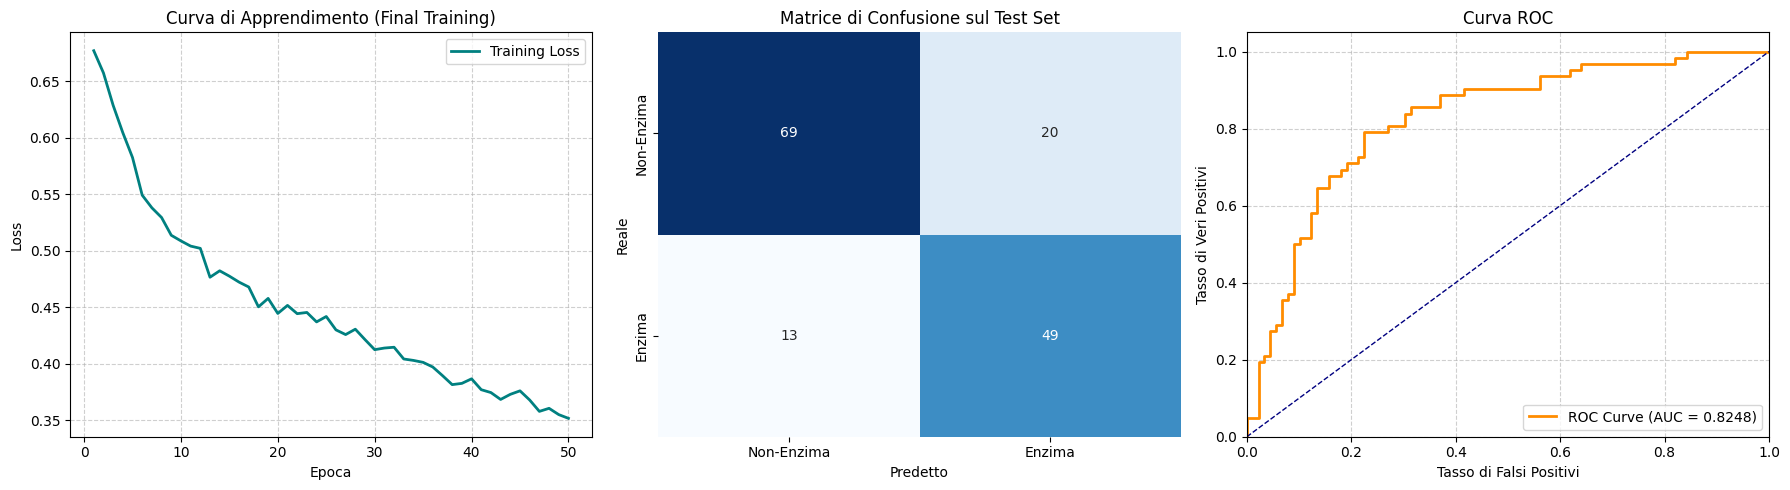

[OK] Tutti gli artefatti d'esame sono stati correttamente esportati nella cartella:
     C:\Users\edoar\Documents\UNIVERSITA'\GitHub\protein-classification-comparison\results


In [11]:
# Valutazione sul Test Set

# Preparazione test set 
test_dataset_normalized = dl.apply_z_score(test_dataset, final_mean, final_std, excluded_features=excluded_indexes)
test_loader = DataLoader(test_dataset_normalized, batch_size=cfg.DEFAULT_BATCH_SIZE, shuffle=False, drop_last=False)

# Valutazione test set
y_test_true, y_test_pred, y_test_score = tr.evaluate_model(final_model, test_loader)

# Calcolo Metriche Definitive
acc = accuracy_score(y_test_true, y_test_pred)
f1_macro = f1_score(y_test_true, y_test_pred, average="macro")
precision = precision_score(y_test_true, y_test_pred, zero_division=0)
recall = recall_score(y_test_true, y_test_pred)
roc_auc = roc_auc_score(y_test_true, y_test_score)

# Esportazione delle metriche definitive del Test Set 
final_metrics = pd.DataFrame({
    "Accuracy": [acc],
    "Macro_F1": [f1_macro],
    "Precision": [precision],
    "Recall": [recall],
    "ROC_AUC": [roc_auc]
})

final_metrics.to_csv(
    cfg.RESULTS_DIR / "final_test_metrics.csv", index=False, float_format="%.4f"
)

print("=============================================================")
print(" METRICHE DEFINITIVE SUL TEST SET (MODELLO VINCENTE) ")
print("=============================================================")
print(f" - Accuracy  : {acc:.4f}")
print(f" - Macro F1  : {f1_macro:.4f}  <-- Metrica di riferimento")
print(f" - Precision : {precision:.4f}  (Capacità di evitare falsi positivi)")
print(f" - Recall    : {recall:.4f}  (Capacità di scovare tutti gli enzimi)")
print(f" - ROC-AUC   : {roc_auc:.4f}")
print("=============================================================\n")

print("\n>> COMPILAZIONE GRAFICI DI VALUTAZIONE FINALI...")

# Plot dei grafici
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Grafico A: Curva di Loss
ax[0].plot(range(1, len(history_loss) + 1), history_loss, label='Training Loss', color='teal', linewidth=2)
ax[0].set_title('Curva di Apprendimento (Final Training)')
ax[0].set_xlabel('Epoca')
ax[0].set_ylabel('Loss')
ax[0].grid(True, linestyle='--', alpha=0.6)
ax[0].legend()

# Grafico B: Matrice di Confusione
cm = confusion_matrix(y_test_true, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[1], cbar=False,
            xticklabels=['Non-Enzima', 'Enzima'], yticklabels=['Non-Enzima', 'Enzima'])
ax[1].set_title('Matrice di Confusione sul Test Set')
ax[1].set_xlabel('Predetto')
ax[1].set_ylabel('Reale')

# Grafico C: Curva ROC
fpr, tpr, _ = roc_curve(y_test_true, y_test_score)
ax[2].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax[2].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
ax[2].set_xlim([0.0, 1.0])
ax[2].set_ylim([0.0, 1.05])
ax[2].set_title('Curva ROC')
ax[2].set_xlabel('Tasso di Falsi Positivi')
ax[2].set_ylabel('Tasso di Veri Positivi')
ax[2].grid(True, linestyle='--', alpha=0.6)
ax[2].legend(loc="lower right")

# Esportazione immagine plot
plt.savefig(cfg.RESULTS_DIR / "final_evaluation_plots.png", dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

plt.close()

print(f"[OK] Tutti gli artefatti d'esame sono stati correttamente esportati nella cartella:\n     {cfg.RESULTS_DIR.resolve()}")